# Maze RL v6 — PPO + CNN

Changes vs v5:
- **Original maze generator** (from assignment files)
- **10000 training mazes** (as specified in the task) — key for generalization
- Proven PPO setup from v5 (conservative, KL early stop)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from collections import deque
import hashlib, random, time, copy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda': print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cpu


## 1. Генератор лабиринтов
`disjoint_set.py`, `rectangular_kruskal_maze.py`, `maze_generator.py`

In [2]:
# ========== disjoint_set.py ==========
from typing import List, Any

class DisjointSet:
    def __init__(self, items: List[Any]):
        self.items = items
        self.parent = [idx for idx in range(len(items))]
        self.size = [1 for _ in range(len(items))]

    def find(self, x: int) -> int:
        item = x
        while item != self.parent[item]:
            item = self.parent[item]
        root = item
        while x != root:
            parent = self.parent[x]
            self.parent[x] = root
            x = parent
        return root

    def union(self, a: int, b: int) -> int:
        root_a = self.find(a)
        root_b = self.find(b)
        if root_a != root_b:
            if self.size[root_a] < self.size[root_b]:
                self.size[root_b] += self.size[root_a]
                self.parent[root_a] = root_b
            else:
                self.size[root_a] += self.size[root_b]
                self.parent[root_b] = root_a
        return root_a


# ========== rectangular_kruskal_maze.py ==========

class KruskalRectangular:
    def __init__(self, n):
        self.n = n
        self.total_cells = n ** 2
        self.TOP = 0
        self.RIGHT = 1
        self.BOTTOM = 2
        self.LEFT = 3

    def create_graph(self):
        edges = []
        for row in range(self.n):
            for col in range(self.n):
                node = self.n * row + col
                if col < self.n - 1:
                    right_node = node + 1
                    edges.append((node, right_node))
                if row < self.n - 1:
                    bottom_node = node + self.n
                    edges.append((node, bottom_node))
        return edges

    def kruskal_spanning_tree(self):
        edges_of_graph = self.create_graph()
        spanning_tree = {
            cell: [0, 0, 0, 0] for cell in range(self.total_cells)
        }
        edges = []
        cells = [idx for idx in range(self.total_cells)]
        disjoint = DisjointSet(cells)
        random.shuffle(edges_of_graph)

        for edge in edges_of_graph:
            cell1, cell2 = edge
            if disjoint.find(cell1) != disjoint.find(cell2):
                disjoint.union(cell1, cell2)
                direction = self.get_neighbour_dir(cell1, cell2)
                spanning_tree[cell1][direction] = 1
                neighbour_dir = self.get_neighbour_dir(cell2, cell1)
                spanning_tree[cell2][neighbour_dir] = 1
                edges.append(edge)
        return spanning_tree, edges

    def get_neighbour_dir(self, cell1, cell2):
        if cell1 == cell2 + self.n:
            return self.TOP
        elif cell1 == cell2 - 1:
            return self.RIGHT
        elif cell1 == cell2 + 1:
            return self.LEFT
        elif cell1 == cell2 - self.n:
            return self.BOTTOM


# ========== maze_generator.py ==========

def make_maze(n: int) -> np.ndarray:
    algo = KruskalRectangular(n)
    spanning_tree, edges = algo.kruskal_spanning_tree()

    size = 2 * n + 1
    result = np.zeros((size, size), dtype=np.int32)

    for i in range(n):
        for j in range(n):
            y, x, node = 2 * i + 1, 2 * j + 1, i * n + j

            result[y, x] = 1
            result[y, x + 1] = j + 1 < n and spanning_tree[node][algo.RIGHT]  or result[y, x + 1]
            result[y + 1, x] = i + 1 < n and spanning_tree[node][algo.BOTTOM] or result[y + 1, x]

    result[1, 0] = result[-2, -1] = 1

    return result, edges


def generate_mazes(n: int, maze_size: int) -> np.ndarray:
    result = []
    hashes = { 'PLACEHOLDER' }

    for i in range(n):
        if (i+1) % 1000 == 0:
            print(f'  {i+1}/{n} mazes generated')
        key = 'PLACEHOLDER'
        while key in hashes:
            maze, edges = make_maze(maze_size)
            key = hashlib.sha256(str(edges).encode()).hexdigest()
        else:
            hashes.add(key)

        result.append(maze)

    return np.stack(result)

## 2. BFS + Среда (numpy-only, 6 каналов)

In [3]:
def bfs_distance_map(maze):
    """BFS от выхода (19,20). Карта расстояний до выхода для каждой клетки."""
    H,W=maze.shape; dist=np.full((H,W),9999.0,dtype=np.float32)
    end=(19,20); dist[end]=0; q=deque([end])
    while q:
        r,c=q.popleft()
        for dr,dc in [(1,0),(0,1),(-1,0),(0,-1)]:
            nr,nc=r+dr,c+dc
            if 0<=nr<H and 0<=nc<W and maze[nr,nc]==1 and dist[nr,nc]>9000:
                dist[nr,nc]=dist[r,c]+1; q.append((nr,nc))
    return dist

def bfs_shortest_path(maze):
    """BFS от входа (1,0) до выхода (19,20). Бинарная маска кратчайшего пути."""
    H,W=maze.shape; start,end=(1,0),(19,20)
    prev={start:None}; q=deque([start])
    while q:
        r,c=q.popleft()
        if (r,c)==end: break
        for dr,dc in [(1,0),(0,1),(-1,0),(0,-1)]:
            nr,nc=r+dr,c+dc
            if 0<=nr<H and 0<=nc<W and maze[nr,nc]==1 and (nr,nc) not in prev:
                prev[(nr,nc)]=(r,c); q.append((nr,nc))
    mask=np.zeros((H,W),dtype=np.float32)
    cell=end
    if cell not in prev: return mask
    while cell is not None: mask[cell]=1.0; cell=prev[cell]
    return mask

def precompute(mazes):
    """Предвычисление BFS-карт расстояний и масок кратчайших путей."""
    n=len(mazes)
    dists=np.zeros_like(mazes,dtype=np.float32)
    sps=np.zeros_like(mazes,dtype=np.float32)
    for i in range(n):
        dists[i]=bfs_distance_map(mazes[i])
        sps[i]=bfs_shortest_path(mazes[i])
        if (i+1)%2000==0: print(f'  BFS: {i+1}/{n}')
    return dists, sps

# CoordConv
COORD_R = np.arange(21).reshape(21,1).repeat(21,axis=1).astype(np.float32)/20.0
COORD_C = np.arange(21).reshape(1,21).repeat(21,axis=0).astype(np.float32)/20.0


class VecMazeEnv:
    """
    Векторизованная среда лабиринта (numpy-only операции в step/reset).
    
    Obs: (N, 6, 21, 21) float32
      Ch 0: maze layout (0=wall, 1=path)
      Ch 1: agent position (one-hot)
      Ch 2: exit position (one-hot)
      Ch 3: visited cells map
      Ch 4: row coordinate [0..1]
      Ch 5: col coordinate [0..1]
    
    Actions: 0=down, 1=right, 2=up, 3=left
    Шаг в стену оставляет агента на месте (игра НЕ заканчивается).
    Игра заканчивается при достижении выхода или max_steps.
    
    Rewards — стационарные (зависят только от BFS-расстояния):
      Stage 1: delta_distance * 0.5 + exit_bonus
      Stage 2: delta_distance * 1.0 + exit_bonus - step_cost
      Stage 3: delta_distance * 1.0 + exit_bonus - step_cost - off_SP_penalty
    """
    GS=21; ER,EC=1,0; XR,XC=19,20
    DR=np.array([1,0,-1,0],dtype=np.int32)
    DC=np.array([0,1,0,-1],dtype=np.int32)
    N_CH=6

    def __init__(self, pool, n_envs, max_steps=400, stage=1,
                 dist_pool=None, sp_pool=None):
        self.pool=pool.astype(np.float32)
        self.n_envs=n_envs; self.max_steps=max_steps; self.stage=stage
        self.dist_pool=dist_pool; self.sp_pool=sp_pool
        N,G=n_envs,self.GS
        self.mazes=np.zeros((N,G,G),dtype=np.float32)
        self.dists=np.zeros((N,G,G),dtype=np.float32)
        self.sps=np.zeros((N,G,G),dtype=np.float32)
        self.pos_r=np.zeros(N,dtype=np.int32)
        self.pos_c=np.zeros(N,dtype=np.int32)
        self.steps=np.zeros(N,dtype=np.int32)
        self.visited=np.zeros((N,G,G),dtype=np.float32)
        self.done=np.zeros(N,dtype=bool)

    def reset(self, idx=None):
        if idx is None: idx=np.arange(self.n_envs)
        mi=np.random.randint(0,len(self.pool),size=len(idx))
        self.mazes[idx]=self.pool[mi]
        if self.dist_pool is not None: self.dists[idx]=self.dist_pool[mi]
        if self.sp_pool is not None: self.sps[idx]=self.sp_pool[mi]
        self.pos_r[idx]=self.ER; self.pos_c[idx]=self.EC
        self.steps[idx]=0; self.visited[idx]=0.0
        self.visited[idx,self.ER,self.EC]=1.0; self.done[idx]=False
        return self._obs()

    def step(self, actions):
        I=np.arange(self.n_envs); alive=~self.done
        old_r,old_c=self.pos_r.copy(),self.pos_c.copy()
        nr=np.clip(self.pos_r+self.DR[actions],0,self.GS-1)
        nc=np.clip(self.pos_c+self.DC[actions],0,self.GS-1)
        walk=self.mazes[I,nr,nc]>0.5; valid=alive&walk
        self.pos_r=np.where(valid,nr,self.pos_r)
        self.pos_c=np.where(valid,nc,self.pos_c)
        self.visited[I,self.pos_r,self.pos_c]=1.0
        stayed=(self.pos_r==old_r)&(self.pos_c==old_c)&alive
        self.steps+=alive.astype(np.int32)
        reached=(self.pos_r==self.XR)&(self.pos_c==self.XC)&alive
        timeout=(self.steps>=self.max_steps)&alive&~reached

        rew=np.zeros(self.n_envs,dtype=np.float32)
        al=alive.astype(np.float32)
        d_old=self.dists[I,old_r,old_c]
        d_new=self.dists[I,self.pos_r,self.pos_c]
        delta_d=(d_old-d_new)*al

        if self.stage==1:
            rew += delta_d*0.5
            rew -= stayed.astype(np.float32)*0.3
            rew += reached.astype(np.float32)*10.0
        elif self.stage==2:
            rew += delta_d*1.0
            rew -= stayed.astype(np.float32)*0.5
            rew -= al*0.01
            rew += reached.astype(np.float32)*20.0
            rew -= timeout.astype(np.float32)*2.0
        elif self.stage==3:
            on_sp=self.sps[I,self.pos_r,self.pos_c]
            off_sp=(1.0-on_sp)*al*valid.astype(np.float32)
            rew += delta_d*1.0
            rew -= stayed.astype(np.float32)*0.5
            rew -= off_sp*0.5
            rew += on_sp*al*0.2
            rew -= al*0.01
            rew += reached.astype(np.float32)*20.0
            rew -= timeout.astype(np.float32)*2.0

        self.done=self.done|reached|timeout
        return self._obs(),rew,self.done.copy(),{
            'reached_exit':reached,'timeout':timeout,'steps':self.steps.copy()}

    def _obs(self):
        obs=np.zeros((self.n_envs,self.N_CH,self.GS,self.GS),dtype=np.float32)
        obs[:,0]=self.mazes; I=np.arange(self.n_envs)
        obs[I,1,self.pos_r,self.pos_c]=1.0; obs[:,2,self.XR,self.XC]=1.0
        obs[:,3]=self.visited; obs[:,4]=COORD_R; obs[:,5]=COORD_C
        return obs

    def auto_reset_done(self):
        di=np.where(self.done)[0]
        if len(di)>0: self.reset(di)
        return self._obs()

## 3. CNN Actor-Critic

In [4]:
class MazeCNN(nn.Module):
    """
    Свёрточная Actor-Critic сеть.
    Вход: (batch, 6, 21, 21)
    Выход: policy_logits (batch, 4), value (batch,)
    """
    def __init__(self, in_ch=6):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.fc = nn.Sequential(nn.Linear(128*3*3, 256), nn.ReLU())
        self.pi_head = nn.Linear(256, 4)
        self.vf_head = nn.Linear(256, 1)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(self.pi_head.weight, gain=0.01)
        nn.init.zeros_(self.pi_head.bias)

    def forward(self, x):
        h = self.conv(x).reshape(x.size(0), -1)
        h = self.fc(h)
        return self.pi_head(h), self.vf_head(h).squeeze(-1)

    def act(self, obs, action=None):
        logits, val = self.forward(obs)
        dist = Categorical(logits=logits)
        if action is None: action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), val

    def get_value(self, obs):
        return self.forward(obs)[1]

model = MazeCNN().to(device)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

Params: 427,493


## 4. PPO (Proximal Policy Optimization)

Реализация по Schulman et al., 2017:
- **Clipped surrogate**: $L = \min(r \cdot A, \text{clip}(r, 1\pm\varepsilon) \cdot A)$
- **GAE** (Generalized Advantage Estimation)
- **KL early stopping**: прерывание эпохи если KL > target
- **Linear LR annealing**

In [5]:
class RolloutBuffer:
    def __init__(self, n_steps, n_envs, obs_shape, dev):
        self.n_steps,self.n_envs,self.dev=n_steps,n_envs,dev
        S=(n_steps,n_envs)
        self.obs=np.zeros((n_steps,n_envs,*obs_shape),dtype=np.float32)
        self.actions=np.zeros(S,dtype=np.int64)
        self.log_probs=np.zeros(S,dtype=np.float32)
        self.rewards=np.zeros(S,dtype=np.float32)
        self.dones=np.zeros(S,dtype=np.float32)
        self.values=np.zeros(S,dtype=np.float32)
        self.ptr=0
    def store(self,obs,act,lp,rew,done,val):
        self.obs[self.ptr]=obs;self.actions[self.ptr]=act
        self.log_probs[self.ptr]=lp;self.rewards[self.ptr]=rew
        self.dones[self.ptr]=done;self.values[self.ptr]=val;self.ptr+=1
    def reset(self): self.ptr=0
    def compute_gae(self,last_val,last_done,gamma=0.99,lam=0.95):
        adv=np.zeros_like(self.rewards);gae=0.0
        for t in reversed(range(self.n_steps)):
            nv=last_val if t==self.n_steps-1 else self.values[t+1]
            nd=last_done if t==self.n_steps-1 else self.dones[t+1]
            delta=self.rewards[t]+gamma*nv*(1-nd)-self.values[t]
            gae=delta+gamma*lam*(1-nd)*gae;adv[t]=gae
        return adv,adv+self.values
    def batches(self,adv,ret,bs):
        T=self.n_steps*self.n_envs;idx=np.random.permutation(T)
        flat=lambda x:x.reshape(T) if x.ndim==2 else x.reshape(T,*x.shape[2:])
        O,A,L,V,AD,R=[flat(x) for x in [self.obs,self.actions,self.log_probs,self.values,adv,ret]]
        for s in range(0,T,bs):
            i=idx[s:s+bs]
            yield(torch.tensor(O[i],device=self.dev),torch.tensor(A[i],device=self.dev),
                  torch.tensor(L[i],device=self.dev),torch.tensor(V[i],device=self.dev),
                  torch.tensor(AD[i],device=self.dev),torch.tensor(R[i],device=self.dev))


class PPO:
    def __init__(self, model, lr=3e-4, gamma=0.99, lam=0.95, clip=0.1,
                 ent_coef=0.02, val_coef=0.25, max_epochs=3, bs=1024,
                 target_kl=0.015, total_iters=800):
        self.model=model;self.gamma=gamma;self.lam=lam;self.clip=clip
        self.ent_coef=ent_coef;self.val_coef=val_coef
        self.max_epochs=max_epochs;self.bs=bs
        self.target_kl=target_kl
        self.lr_start=lr;self.total_iters=total_iters
        self.opt=optim.Adam(model.parameters(),lr=lr,eps=1e-5)
        self.iter_count=0

    def update(self, buf, last_val, last_done):
        self.iter_count+=1
        frac=max(1.0-self.iter_count/self.total_iters,0.1)
        lr=self.lr_start*frac
        for pg in self.opt.param_groups: pg['lr']=lr
        adv,ret=buf.compute_gae(last_val,last_done,self.gamma,self.lam)
        adv=(adv-adv.mean())/(adv.std()+1e-8)
        st={'pl':0,'vl':0,'ent':0,'cf':0,'kl':0};nu=0;epochs_done=0
        for epoch in range(self.max_epochs):
            epoch_kl=0;epoch_n=0
            for obs,act,old_lp,old_v,ad,rt in buf.batches(adv,ret,self.bs):
                _,new_lp,ent,new_v=self.model.act(obs,act)
                log_ratio=new_lp-old_lp;ratio=log_ratio.exp()
                with torch.no_grad():
                    approx_kl=((ratio-1)-log_ratio).mean().item()
                    epoch_kl+=approx_kl;epoch_n+=1
                s1=ratio*ad;s2=ratio.clamp(1-self.clip,1+self.clip)*ad
                pl=-torch.min(s1,s2).mean()
                vl=0.5*(new_v-rt).pow(2).mean()
                loss=pl+self.val_coef*vl-self.ent_coef*ent.mean()
                self.opt.zero_grad();loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(),0.5)
                self.opt.step()
                with torch.no_grad():
                    st['pl']+=pl.item();st['vl']+=vl.item()
                    st['ent']+=ent.mean().item()
                    st['cf']+=((ratio-1).abs()>self.clip).float().mean().item()
                    st['kl']+=approx_kl;nu+=1
            epochs_done+=1
            if epoch_n>0 and epoch_kl/epoch_n>self.target_kl: break
        r={k:v/max(nu,1) for k,v in st.items()}
        r['lr']=lr;r['epochs']=epochs_done
        return r

    def collect(self, env, buf, obs):
        buf.reset();ep_infos=[]
        for _ in range(buf.n_steps):
            with torch.no_grad():
                t=torch.tensor(obs,device=device)
                act,lp,_,val=self.model.act(t)
            a,l,v=act.cpu().numpy(),lp.cpu().numpy(),val.cpu().numpy()
            nobs,rew,done,info=env.step(a)
            buf.store(obs,a,l,rew,done.astype(np.float32),v)
            for i in range(env.n_envs):
                if info['reached_exit'][i] or info['timeout'][i]:
                    ep_infos.append({'exit':bool(info['reached_exit'][i]),
                                     'steps':int(info['steps'][i])})
            obs=env.auto_reset_done()
        return obs,ep_infos

## 5. Генерация данных (10000 лабиринтов)

In [6]:
N_TRAIN = 10000 
N_EVAL = 200

print(f'Generating {N_TRAIN} training mazes')
train_mazes = generate_mazes(N_TRAIN, maze_size=10)
print(f'Generating {N_EVAL} eval mazes')
eval_mazes = generate_mazes(N_EVAL, maze_size=10)

print(f'\nMaze shape: {train_mazes[0].shape}')
print(f'Entry: (1,0)={train_mazes[0,1,0]}, Exit: (19,20)={train_mazes[0,19,20]}')

print(f'\nPrecomputing BFS for {N_TRAIN} train mazes')
train_dist, train_sp = precompute(train_mazes)
print(f'Precomputing BFS for {N_EVAL} eval mazes')
eval_dist, eval_sp = precompute(eval_mazes)

avg_sp = train_sp.sum(axis=(1,2)).mean()
print(f'\nAvg shortest path: {avg_sp:.0f} cells')
print(f'Avg BFS entry-exit: {train_dist[:,1,0].mean():.0f}')

Generating 10000 training mazes
  1000/10000 mazes generated
  2000/10000 mazes generated
  3000/10000 mazes generated
  4000/10000 mazes generated
  5000/10000 mazes generated
  6000/10000 mazes generated
  7000/10000 mazes generated
  8000/10000 mazes generated
  9000/10000 mazes generated
  10000/10000 mazes generated
Generating 200 eval mazes

Maze shape: (21, 21)
Entry: (1,0)=1, Exit: (19,20)=1

Precomputing BFS for 10000 train mazes
  BFS: 2000/10000
  BFS: 4000/10000
  BFS: 6000/10000
  BFS: 8000/10000
  BFS: 10000/10000
Precomputing BFS for 200 eval mazes

Avg shortest path: 50 cells
Avg BFS entry-exit: 49


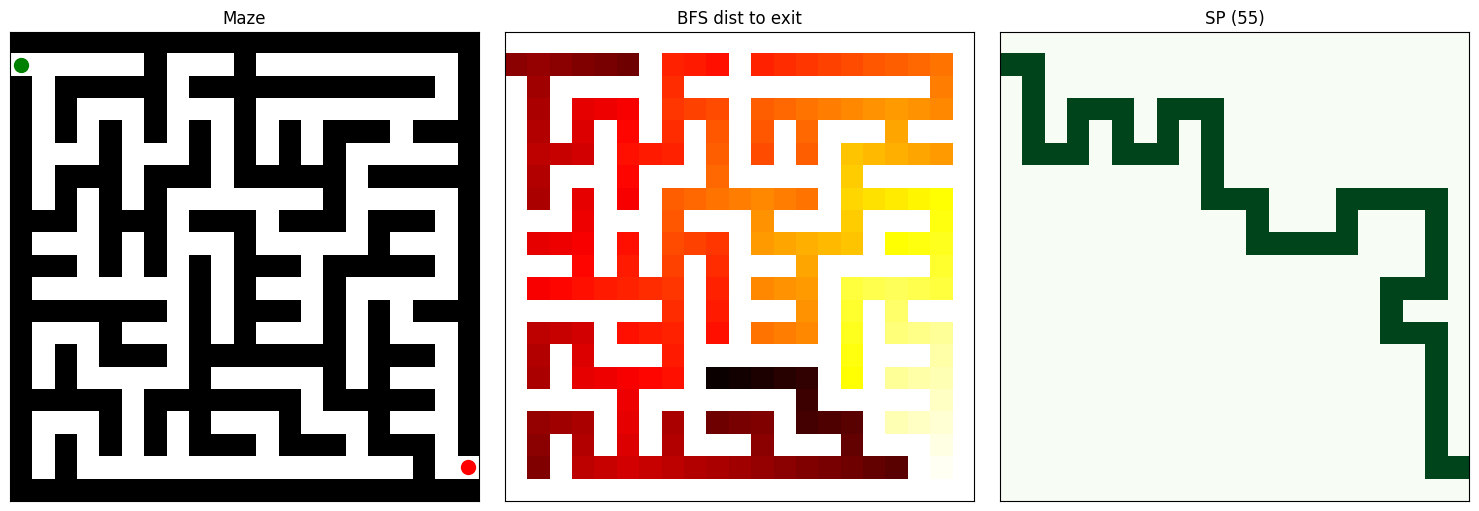

In [7]:
fig,axes=plt.subplots(1,3,figsize=(15,5))
i=0
axes[0].imshow(train_mazes[i],cmap='binary_r'); axes[0].set_title('Maze')
axes[0].plot(0,1,'go',ms=10); axes[0].plot(20,19,'ro',ms=10)
d=train_dist[i].copy(); d[d>500]=np.nan
axes[1].imshow(d,cmap='hot_r'); axes[1].set_title('BFS dist to exit')
axes[2].imshow(train_sp[i],cmap='Greens'); axes[2].set_title(f'SP ({int(train_sp[i].sum())})')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 6. Обучение

In [8]:
OBS_SHAPE = (6, 21, 21)

def evaluate_model(model, mazes, dists, sps, stage, n=200, ms=400, n_runs=3):
    total_r,total_s,total_rc=0,0,0
    for _ in range(n_runs):
        env=VecMazeEnv(mazes,n,ms,stage,dists,sps)
        obs=env.reset()
        reached=np.zeros(n,dtype=bool);steps_a=np.zeros(n,dtype=np.int32)
        done_f=np.zeros(n,dtype=bool)
        for _ in range(ms):
            with torch.no_grad():
                actions,_,_,_=model.act(torch.tensor(obs,device=device))
                actions=actions.cpu().numpy()
            obs,_,_,info=env.step(actions)
            for i in range(n):
                if (info['reached_exit'][i] or info['timeout'][i]) and not done_f[i]:
                    reached[i]=info['reached_exit'][i];steps_a[i]=info['steps'][i]
                    done_f[i]=True
            if done_f.all(): break
        total_r+=reached.sum()
        if reached.any(): total_s+=steps_a[reached].sum();total_rc+=reached.sum()
    sr=total_r/(n*n_runs)
    avg_s=total_s/total_rc if total_rc>0 else ms
    return sr, avg_s

def plot_curves(hist,title):
    fig,axes=plt.subplots(1,4,figsize=(18,3.5))
    for ax,key,lab in zip(axes,['exit_rate','avg_steps','pl','ent'],
        ['Train Exit Rate','Avg Steps','Policy Loss','Entropy']):
        data=hist[key];ax.plot(data,alpha=0.3,color='C0')
        w=min(30,max(1,len(data)//5))
        if len(data)>w:
            sm=np.convolve(data,np.ones(w)/w,'valid')
            ax.plot(range(w-1,len(data)),sm,'C0',lw=2)
        ax.set_title(lab);ax.grid(True,alpha=0.3);ax.set_xlabel('Iter')
    if hist.get('eval_sr'):
        ax2=axes[0].twinx()
        ax2.plot(hist['eval_iter'],hist['eval_sr'],'r*-',ms=8,label='Eval SR')
        ax2.set_ylabel('Eval SR',color='r');ax2.legend(loc='lower right')
    fig.suptitle(title,fontsize=13);plt.tight_layout();plt.show()

In [22]:
N_ENVS = 64
N_STEPS = 512
MAX_STEPS = 400

STAGES = {
    1: {'name':'Exploration',   'iters':1500,  'lr':3e-4, 'ent':0.02, 'target_kl':0.015},
    2: {'name':'Goal-seeking',  'iters':1500, 'lr':2e-4, 'ent':0.015, 'target_kl':0.012},
    3: {'name':'Shortest path', 'iters':1500, 'lr':1e-4, 'ent':0.01, 'target_kl':0.01},
}

In [23]:
EARLY_STOP = {
    1: {
        'target_sr': 0.98,      # считаем стадию достаточно освоенной
        'stable_needed': 3,     # сколько eval подряд держать этот уровень
        'patience': 15,          # сколько eval ждать улучшений
        'min_delta': 0.005,     # минимальное улучшение success rate
        'use_steps': False,     # шаги на 1 стадии не главный критерий
        'steps_factor': None,
    },
    2: {
        'target_sr': 0.99,
        'stable_needed': 3,
        'patience': 13,
        'min_delta': 0.005,
        'use_steps': False,
        'steps_factor': None,
    },
    3: {
        'target_sr': 0.99,
        'stable_needed': 4,
        'patience': 13,
        'min_delta': 0.003,
        'use_steps': True,      # на 3 стадии уже важна и длина пути
        'steps_factor': 1.15,   # avg_steps <= 1.15 * среднего shortest path
    },
}

In [12]:
# def train_stage(stage, model):
#     cfg=STAGES[stage]; n_iter=cfg['iters']
#     print(f"\n{'='*60}")
#     print(f"  STAGE {stage}: {cfg['name']}")
#     print(f"  iters={n_iter}, lr={cfg['lr']}, ent={cfg['ent']}, target_kl={cfg['target_kl']}")
#     print(f"{'='*60}")
#     env=VecMazeEnv(train_mazes,N_ENVS,MAX_STEPS,stage,train_dist,train_sp)
#     ppo=PPO(model,lr=cfg['lr'],clip=0.1,ent_coef=cfg['ent'],val_coef=0.25,
#             max_epochs=3,bs=1024,target_kl=cfg['target_kl'],total_iters=n_iter)
#     buf=RolloutBuffer(N_STEPS,N_ENVS,OBS_SHAPE,device)
#     obs=env.reset()
#     hist={'exit_rate':[],'avg_steps':[],'pl':[],'ent':[],'eval_sr':[],'eval_iter':[]}
#     log_every=max(1,n_iter//30); eval_every=max(1,n_iter//10)
#     t0=time.time(); best_sr=0; best_state=None

#     for it in range(1,n_iter+1):
#         obs,eps=ppo.collect(env,buf,obs)
#         with torch.no_grad():
#             lv=model.get_value(torch.tensor(obs,device=device)).cpu().numpy()
#         m=ppo.update(buf,lv,env.done.astype(np.float32))
#         exits=sum(1 for e in eps if e['exit'])
#         er=exits/max(len(eps),1)
#         avg_s=np.mean([e['steps'] for e in eps]) if eps else MAX_STEPS
#         hist['exit_rate'].append(er);hist['avg_steps'].append(avg_s)
#         hist['pl'].append(m['pl']);hist['ent'].append(m['ent'])
#         if it%log_every==0:
#             fps=(it*N_STEPS*N_ENVS)/(time.time()-t0)
#             print(f"  {it:4d}/{n_iter} | Exit:{er:.0%} | Steps:{avg_s:.0f} | "
#                   f"PL:{m['pl']:.4f} | Ent:{m['ent']:.3f} | "
#                   f"KL:{m['kl']:.4f} | Ep:{m['epochs']:.0f} | LR:{m['lr']:.1e} | FPS:{fps:.0f}")
#         if it%eval_every==0:
#             sr,avs=evaluate_model(model,eval_mazes,eval_dist,eval_sp,stage)
#             hist['eval_sr'].append(sr);hist['eval_iter'].append(it)
#             if sr>best_sr+0.005:
#                 best_sr=sr;best_state=copy.deepcopy(model.state_dict())
#                 print(f"  ::: EVAL: Success={sr:.1%}, Steps={avs:.1f} *** BEST")
#             else:
#                 print(f"  ::: EVAL: Success={sr:.1%}, Steps={avs:.1f}")

#     if best_state is not None:
#         model.load_state_dict(best_state)
#         print(f"  Loaded best checkpoint (sr={best_sr:.1%})")
#     sr,avs=evaluate_model(model,eval_mazes,eval_dist,eval_sp,stage)
#     print(f"\n  Final: Success={sr:.1%}, Steps={avs:.1f}")
#     plot_curves(hist,f'Stage {stage}: {cfg["name"]}')
#     return model

In [24]:
def train_stage(stage, model):
    cfg = STAGES[stage]
    es = EARLY_STOP[stage]
    n_iter = cfg['iters']

    print(f"\n{'='*60}")
    print(f"  STAGE {stage}: {cfg['name']}")
    print(f"  iters={n_iter}, lr={cfg['lr']}, ent={cfg['ent']}, target_kl={cfg['target_kl']}")
    print(f"  early_stop: target_sr={es['target_sr']}, stable_needed={es['stable_needed']}, patience={es['patience']}")
    print(f"{'='*60}")

    env = VecMazeEnv(train_mazes, N_ENVS, MAX_STEPS, stage, train_dist, train_sp)
    ppo = PPO(
        model,
        lr=cfg['lr'],
        clip=0.1,
        ent_coef=cfg['ent'],
        val_coef=0.25,
        max_epochs=3,
        bs=1024,
        target_kl=cfg['target_kl'],
        total_iters=n_iter
    )
    buf = RolloutBuffer(N_STEPS, N_ENVS, OBS_SHAPE, device)

    obs = env.reset()
    hist = {
        'exit_rate': [],
        'avg_steps': [],
        'pl': [],
        'ent': [],
        'eval_sr': [],
        'eval_iter': [],
    }

    log_every = max(1, n_iter // 30)
    # eval_every = max(1, n_iter // 10)
    eval_every = max(20, n_iter // 20)

    t0 = time.time()
    best_sr = 0.0
    best_avs = float('inf')
    best_state = None

    no_improve = 0
    stable_count = 0

    # ориентир по "хорошим" шагам только для Stage 3
    sp_avg = eval_sp.sum(axis=(1, 2)).mean()

    for it in range(1, n_iter + 1):
        obs, eps = ppo.collect(env, buf, obs)

        with torch.no_grad():
            lv = model.get_value(torch.tensor(obs, device=device)).cpu().numpy()

        m = ppo.update(buf, lv, env.done.astype(np.float32))

        exits = sum(1 for e in eps if e['exit'])
        er = exits / max(len(eps), 1)
        avg_s = np.mean([e['steps'] for e in eps]) if eps else MAX_STEPS

        hist['exit_rate'].append(er)
        hist['avg_steps'].append(avg_s)
        hist['pl'].append(m['pl'])
        hist['ent'].append(m['ent'])

        if it % log_every == 0:
            fps = (it * N_STEPS * N_ENVS) / (time.time() - t0)
            print(
                f"  {it:4d}/{n_iter} | Exit:{er:.0%} | Steps:{avg_s:.0f} | "
                f"PL:{m['pl']:.4f} | Ent:{m['ent']:.3f} | "
                f"KL:{m['kl']:.4f} | Ep:{m['epochs']:.0f} | LR:{m['lr']:.1e} | FPS:{fps:.0f}"
            )

        if it % eval_every == 0:
            sr, avs = evaluate_model(model, eval_mazes, eval_dist, eval_sp, stage)
            hist['eval_sr'].append(sr)
            hist['eval_iter'].append(it)

            improved = False

            # Сначала сравниваем success rate
            if sr > best_sr + es['min_delta']:
                improved = True
            # Если SR почти тот же, но шагов стало заметно меньше — тоже считаем улучшением
            elif abs(sr - best_sr) <= es['min_delta'] and avs < best_avs - 2:
                improved = True

            if improved:
                best_sr = sr
                best_avs = avs
                best_state = copy.deepcopy(model.state_dict())
                no_improve = 0
                print(f"  ::: EVAL: Success={sr:.1%}, Steps={avs:.1f} *** BEST")
            else:
                no_improve += 1
                print(f"  ::: EVAL: Success={sr:.1%}, Steps={avs:.1f} | no_improve={no_improve}/{es['patience']}")

            # Проверка на "стабильно хорошо"
            good_sr = sr >= es['target_sr']

            if es['use_steps']:
                good_steps = avs <= es['steps_factor'] * sp_avg
                if good_sr and good_steps:
                    stable_count += 1
                else:
                    stable_count = 0
                print(
                    f"stable_check: sr_ok={good_sr} | "
                    f"steps_ok={good_steps} (avg_steps={avs:.1f}, threshold={es['steps_factor'] * sp_avg:.1f}) | "
                    f"stable={stable_count}/{es['stable_needed']}"
                )
            else:
                if good_sr:
                    stable_count += 1
                else:
                    stable_count = 0
                print(f"stable_check: sr_ok={good_sr} | stable={stable_count}/{es['stable_needed']}")

            if stable_count >= es['stable_needed']:
                print(f"Early stop: stable target quality reached")
                break

            if no_improve >= es['patience']:
                print(f"Early stop: no meaningful improvement for {es['patience']} evals")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best checkpoint (sr={best_sr:.1%}, steps={best_avs:.1f})")

    sr, avs = evaluate_model(model, eval_mazes, eval_dist, eval_sp, stage)
    print(f"\nFinal: Success={sr:.1%}, Steps={avs:.1f}")
    plot_curves(hist, f"Stage {stage}: {cfg['name']}")

    return model

### Стадия 1: Исследование
Модель блуждает по лабиринту, посещает новые клетки. Без штрафа за длину пути.


  STAGE 1: Exploration
  iters=1000, lr=0.0003, ent=0.02, target_kl=0.015
  early_stop: target_sr=0.98, stable_needed=3, patience=5
    33/1000 | Exit:0% | Steps:400 | PL:-0.0021 | Ent:1.307 | KL:0.0024 | Ep:3 | LR:2.9e-04 | FPS:1936
  ::: EVAL: Success=0.0%, Steps=400.0 *** BEST
stable_check: sr_ok=False | stable=0/3
    66/1000 | Exit:0% | Steps:400 | PL:-0.0019 | Ent:0.588 | KL:0.0041 | Ep:3 | LR:2.8e-04 | FPS:1875
    99/1000 | Exit:0% | Steps:400 | PL:0.0002 | Ent:0.591 | KL:0.0050 | Ep:3 | LR:2.7e-04 | FPS:1755
  ::: EVAL: Success=0.0%, Steps=400.0 | no_improve=1/5
stable_check: sr_ok=False | stable=0/3
   132/1000 | Exit:0% | Steps:400 | PL:-0.0023 | Ent:0.589 | KL:0.0049 | Ep:3 | LR:2.6e-04 | FPS:1716
  ::: EVAL: Success=0.0%, Steps=400.0 | no_improve=2/5
stable_check: sr_ok=False | stable=0/3
   165/1000 | Exit:0% | Steps:400 | PL:-0.0028 | Ent:0.573 | KL:0.0049 | Ep:3 | LR:2.5e-04 | FPS:1672
   198/1000 | Exit:0% | Steps:400 | PL:-0.0032 | Ent:0.612 | KL:0.0048 | Ep:3 | LR:2

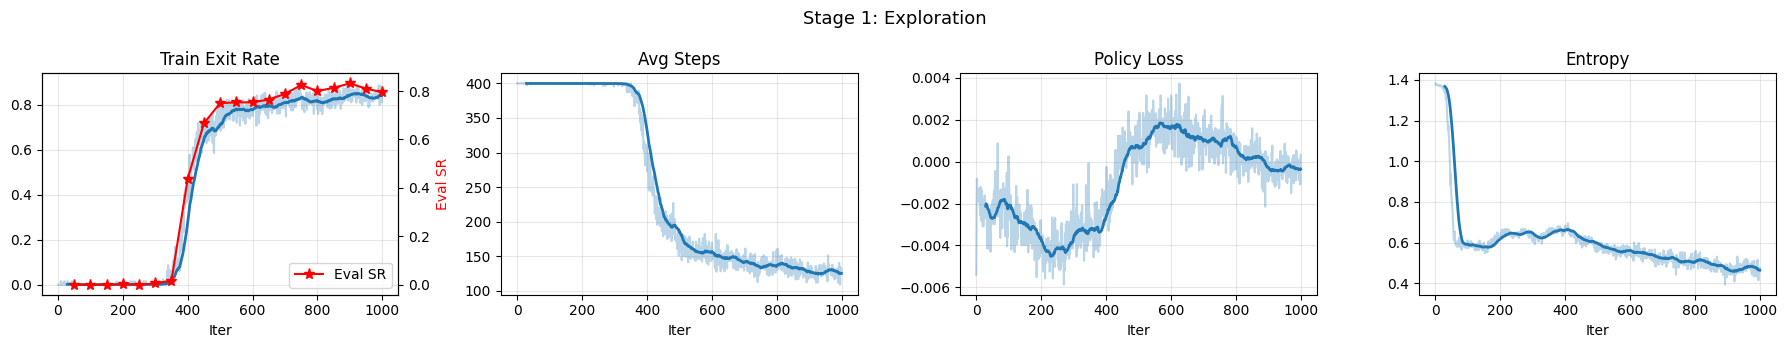

In [15]:
model = MazeCNN().to(device)
model = train_stage(1, model)

In [16]:
# Сохранение
torch.save(model.state_dict(), 'model_stage1.pt')

In [ ]:
# Загрузка
# model = MazeCNN().to(device)
# model.load_state_dict(torch.load('model_stage1.pt', map_location=device))

### Стадия 2: Поиск выхода
Модель стремится к выходу, пытаясь найти кратчайший путь. Штраф за длину пути.


  STAGE 2: Goal-seeking
  iters=1000, lr=0.0002, ent=0.015, target_kl=0.012
  early_stop: target_sr=0.99, stable_needed=3, patience=6
    33/1000 | Exit:76% | Steps:160 | PL:0.0178 | Ent:0.519 | KL:0.0190 | Ep:1 | LR:1.9e-04 | FPS:4405
  ::: EVAL: Success=71.3%, Steps=83.1 *** BEST
stable_check: sr_ok=False | stable=0/3
    66/1000 | Exit:76% | Steps:154 | PL:0.0152 | Ent:0.557 | KL:0.0185 | Ep:1 | LR:1.9e-04 | FPS:4194
    99/1000 | Exit:78% | Steps:154 | PL:0.0117 | Ent:0.524 | KL:0.0136 | Ep:1 | LR:1.8e-04 | FPS:4228
  ::: EVAL: Success=76.3%, Steps=84.9 *** BEST
stable_check: sr_ok=False | stable=0/3
   132/1000 | Exit:71% | Steps:176 | PL:0.0103 | Ent:0.585 | KL:0.0129 | Ep:1 | LR:1.7e-04 | FPS:4248
  ::: EVAL: Success=63.8%, Steps=86.1 | no_improve=1/6
stable_check: sr_ok=False | stable=0/3
   165/1000 | Exit:68% | Steps:181 | PL:0.0122 | Ent:0.559 | KL:0.0177 | Ep:1 | LR:1.7e-04 | FPS:4127
   198/1000 | Exit:68% | Steps:188 | PL:0.0065 | Ent:0.568 | KL:0.0111 | Ep:3 | LR:1.6e-0

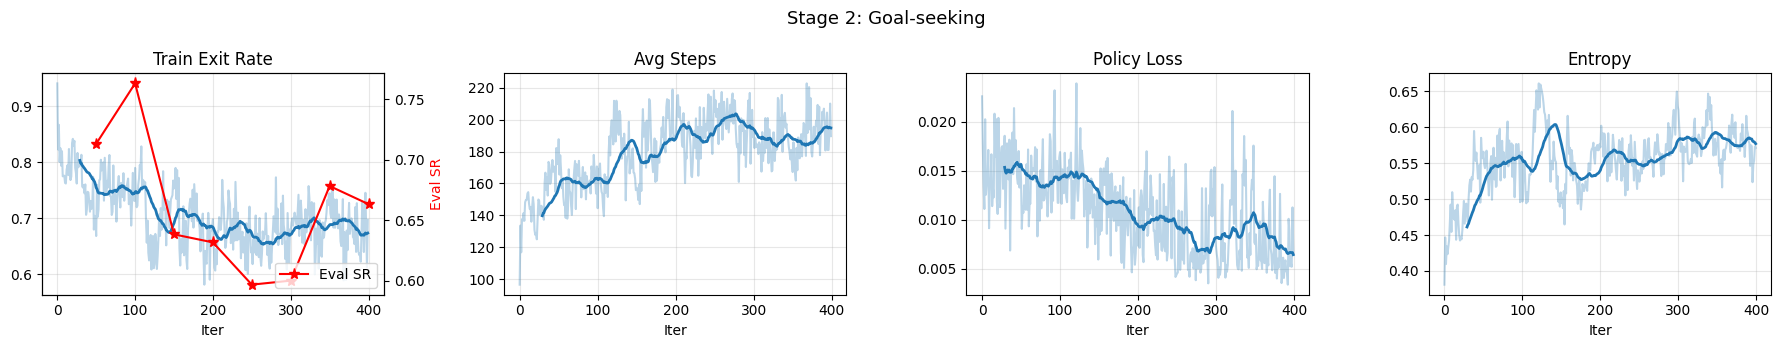

In [17]:
model = train_stage(2, model)

### Стадия 3: Кратчайший путь
Модель идёт строго по кратчайшему пути. Среде известен кратчайший путь, штраф за посещение клеток не принадлежащих этому пути.


  STAGE 3: Shortest path
  iters=1000, lr=0.0001, ent=0.01, target_kl=0.01
  early_stop: target_sr=0.99, stable_needed=4, patience=8
    33/1000 | Exit:64% | Steps:195 | PL:0.0115 | Ent:0.591 | KL:0.0134 | Ep:1 | LR:9.7e-05 | FPS:4535
  ::: EVAL: Success=64.2%, Steps=85.0 *** BEST
stable_check: sr_ok=False | steps_ok=False (avg_steps=85.0, threshold=57.5) | stable=0/4
    66/1000 | Exit:72% | Steps:165 | PL:0.0111 | Ent:0.485 | KL:0.0113 | Ep:1 | LR:9.3e-05 | FPS:4301
    99/1000 | Exit:69% | Steps:177 | PL:0.0131 | Ent:0.514 | KL:0.0151 | Ep:1 | LR:9.0e-05 | FPS:4335
  ::: EVAL: Success=65.8%, Steps=81.5 *** BEST
stable_check: sr_ok=False | steps_ok=False (avg_steps=81.5, threshold=57.5) | stable=0/4
   132/1000 | Exit:59% | Steps:208 | PL:0.0098 | Ent:0.551 | KL:0.0104 | Ep:2 | LR:8.7e-05 | FPS:4104
  ::: EVAL: Success=57.3%, Steps=76.5 | no_improve=1/8
stable_check: sr_ok=False | steps_ok=False (avg_steps=76.5, threshold=57.5) | stable=0/4
   165/1000 | Exit:54% | Steps:231 | PL:0.

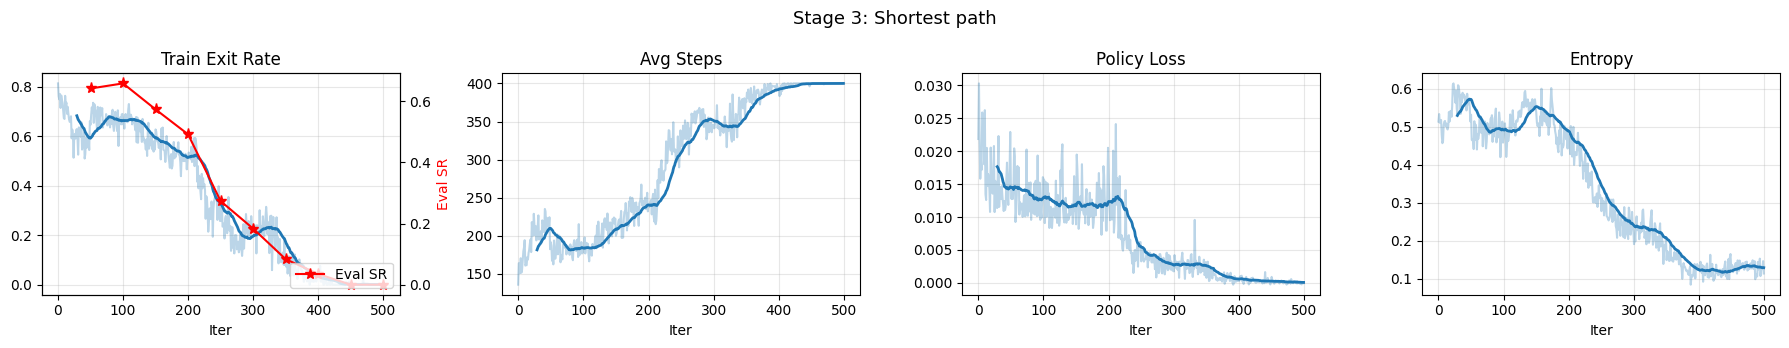

In [18]:
model = train_stage(3, model)

## 7. Итоговая оценка

In [19]:
print('#'*60)
print('  ИТОГОВАЯ ОЦЕНКА НА ТЕСТОВЫХ ЛАБИРИНТАХ')
print('#'*60)
for st in [1,2,3]:
    sr,avs=evaluate_model(model,eval_mazes,eval_dist,eval_sp,st)
    sp_avg = eval_sp.sum(axis=(1,2)).mean()
    print(f'  Stage {st}: Success={sr:.1%}, Avg steps={avs:.1f} (SP avg={sp_avg:.0f})')

############################################################
  ИТОГОВАЯ ОЦЕНКА НА ТЕСТОВЫХ ЛАБИРИНТАХ
############################################################
  Stage 1: Success=69.3%, Avg steps=75.9 (SP avg=50)
  Stage 2: Success=64.7%, Avg steps=78.0 (SP avg=50)
  Stage 3: Success=64.2%, Avg steps=80.5 (SP avg=50)


## 8. Визуализация решений

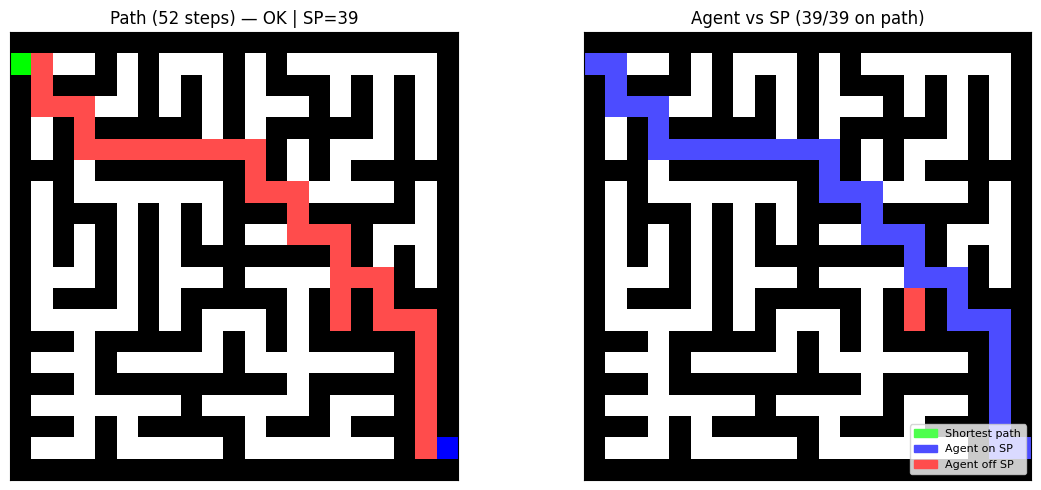

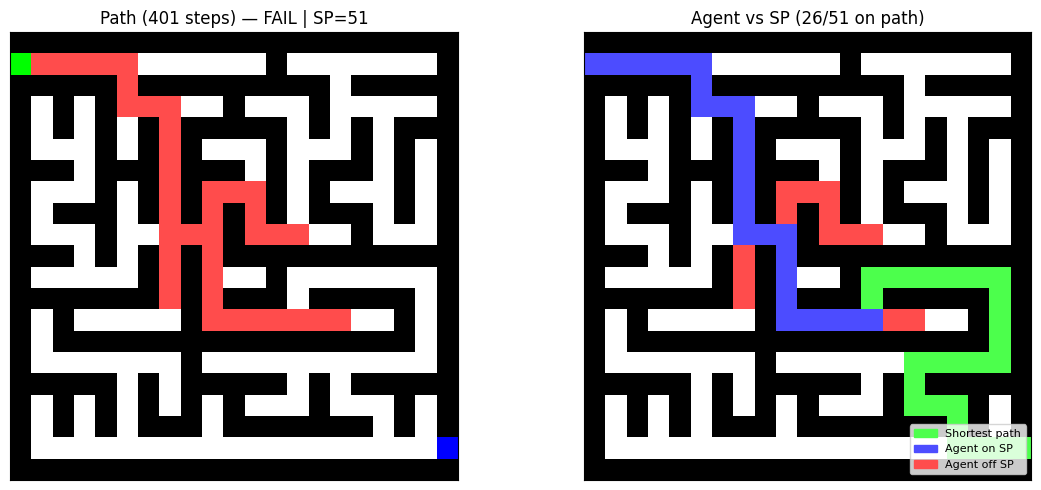

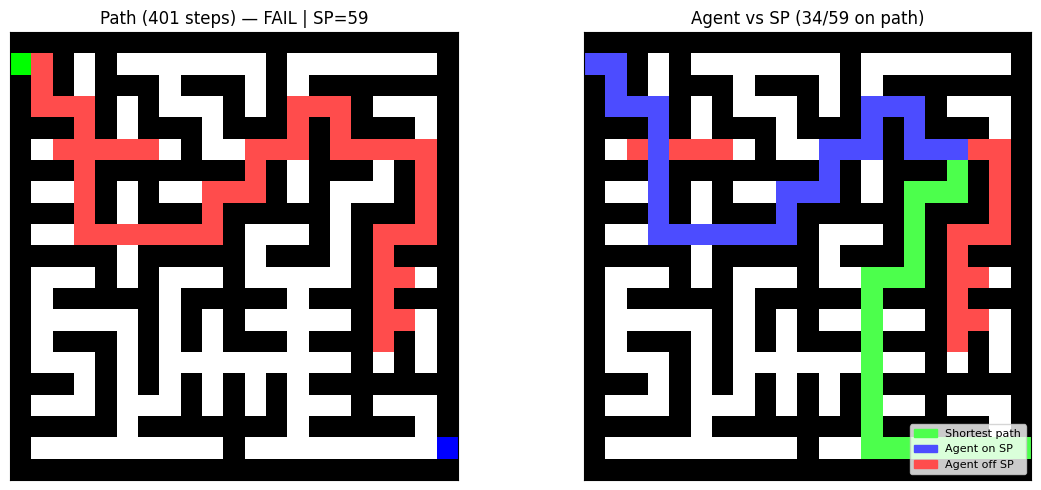

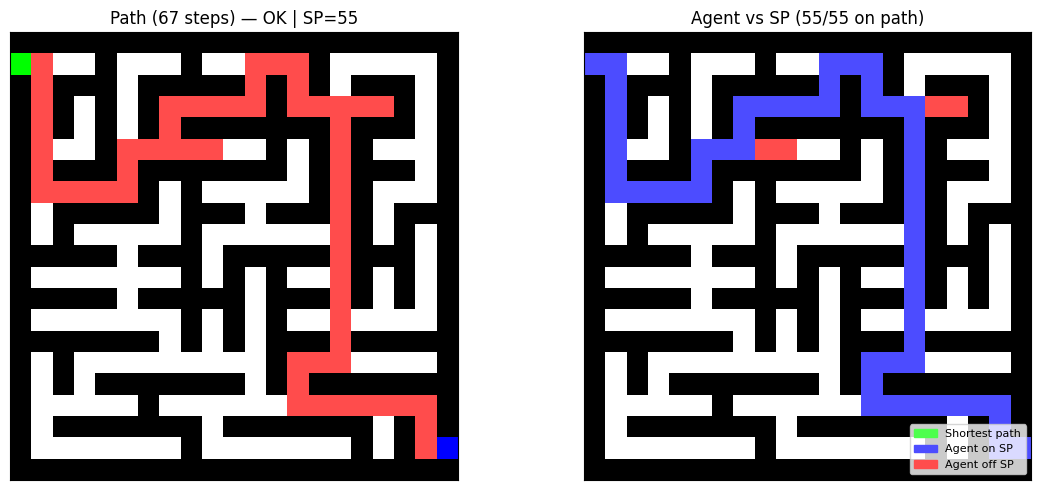

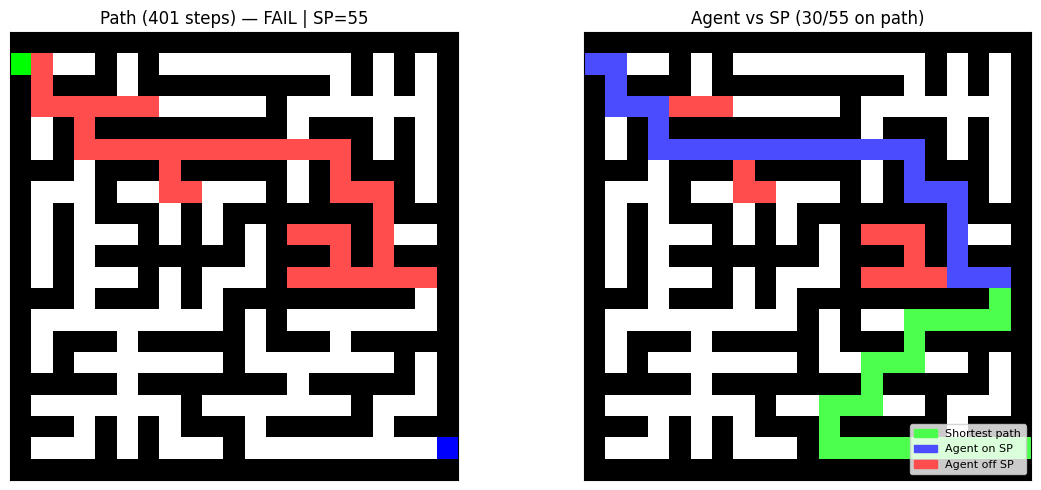

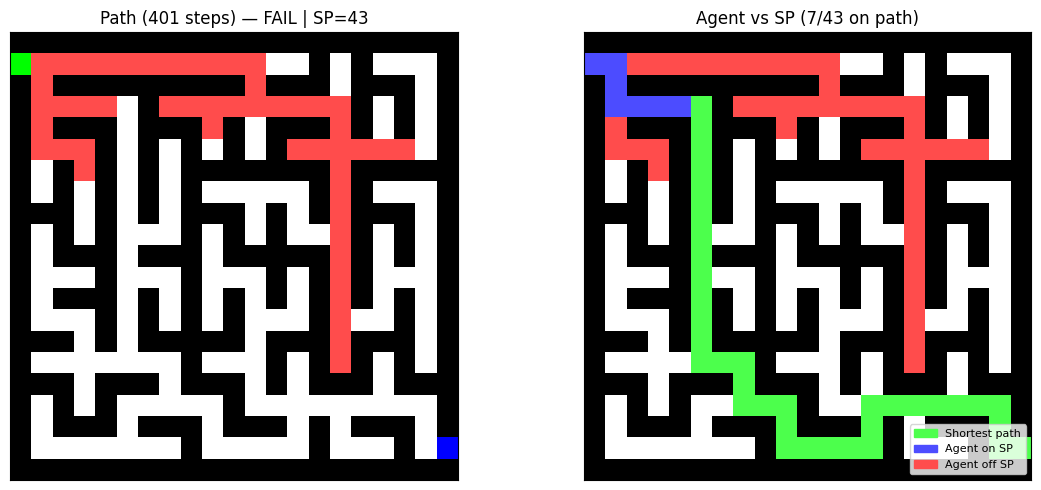

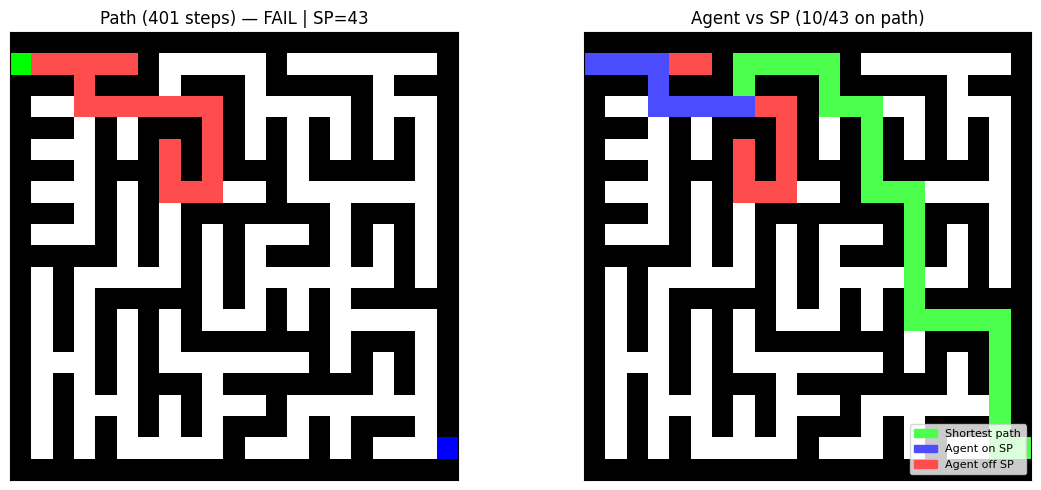

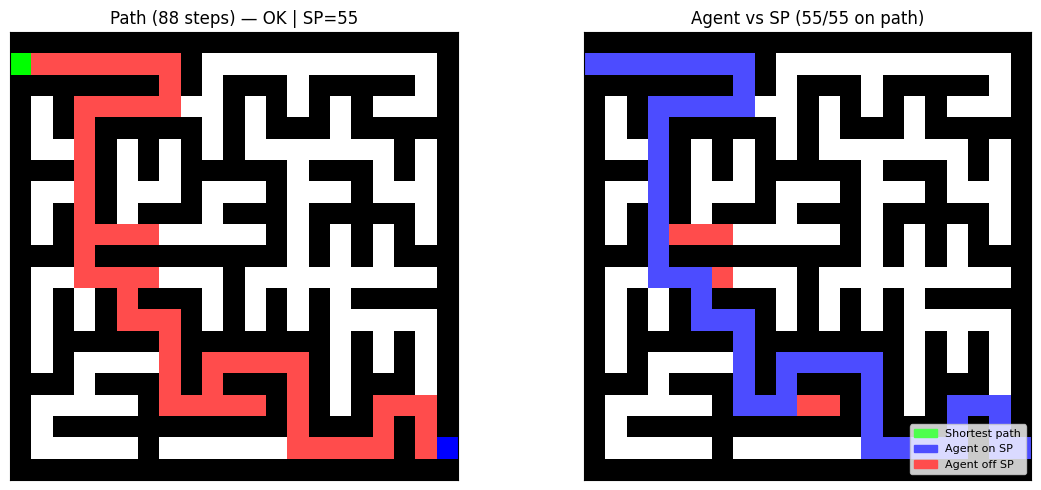

In [20]:
def visualize_solution(model, maze, sp_mask, max_steps=400):
    mf=maze.astype(np.float32); r,c=1,0; path=[(r,c)]
    visited=np.zeros((21,21),dtype=np.float32); visited[r,c]=1.0
    for _ in range(max_steps):
        if r==19 and c==20: break
        obs=np.zeros((1,6,21,21),dtype=np.float32)
        obs[0,0]=mf;obs[0,1,r,c]=1.0;obs[0,2,19,20]=1.0
        obs[0,3]=visited;obs[0,4]=COORD_R;obs[0,5]=COORD_C
        with torch.no_grad():
            actions,_,_,_=model.act(torch.tensor(obs,device=device))
            action=actions.item()
        dr=[1,0,-1,0][action];dc=[0,1,0,-1][action]
        nr,nc=r+dr,c+dc
        if 0<=nr<21 and 0<=nc<21 and maze[nr,nc]==1: r,c=nr,nc
        visited[r,c]=1.0; path.append((r,c))
    reached=(r==19 and c==20)
    sp_len=int(sp_mask.sum())
    on_sp_count=sum(1 for pr,pc in set(path) if sp_mask[pr,pc]>0.5)
    
    fig,axes=plt.subplots(1,2,figsize=(12,5))
    img=np.stack([maze.astype(float)]*3,axis=-1)
    for pr,pc in path: img[pr,pc]=[1,0.3,0.3]
    img[1,0]=[0,1,0]; img[19,20]=[0,0,1]; axes[0].imshow(img)
    axes[0].set_title(f"Path ({len(path)} steps) — {'OK' if reached else 'FAIL'} | SP={sp_len}")
    img2=np.stack([maze.astype(float)]*3,axis=-1)
    for ri,ci in zip(*np.where(sp_mask>0)): img2[ri,ci]=[0.3,1,0.3]
    for pr,pc in path:
        img2[pr,pc]=[0.3,0.3,1] if sp_mask[pr,pc]>0.5 else [1,0.3,0.3]
    axes[1].imshow(img2)
    axes[1].set_title(f'Agent vs SP ({on_sp_count}/{sp_len} on path)')
    axes[1].legend(handles=[
        mpatches.Patch(color=(0.3,1,0.3),label='Shortest path'),
        mpatches.Patch(color=(0.3,0.3,1),label='Agent on SP'),
        mpatches.Patch(color=(1,0.3,0.3),label='Agent off SP'),
    ],loc='lower right',fontsize=8)
    for ax in axes: ax.set_xticks([]);ax.set_yticks([])
    plt.tight_layout(); plt.show()

for _ in range(8):
    i=np.random.randint(len(eval_mazes))
    visualize_solution(model,eval_mazes[i],eval_sp[i])

In [21]:
torch.save(model.state_dict(), 'maze_solver_v6.pt')

Model saved!


## Тест 2


  STAGE 1: Exploration
  iters=1500, lr=0.0003, ent=0.02, target_kl=0.015
  early_stop: target_sr=0.98, stable_needed=3, patience=15
    50/1500 | Exit:0% | Steps:400 | PL:-0.0020 | Ent:0.927 | KL:0.0024 | Ep:3 | LR:2.9e-04 | FPS:1936
  ::: EVAL: Success=0.0%, Steps=400.0 *** BEST
stable_check: sr_ok=False | stable=0/3
   100/1500 | Exit:0% | Steps:400 | PL:-0.0034 | Ent:0.556 | KL:0.0040 | Ep:3 | LR:2.8e-04 | FPS:1932
   150/1500 | Exit:0% | Steps:400 | PL:-0.0010 | Ent:0.560 | KL:0.0049 | Ep:3 | LR:2.7e-04 | FPS:1942
  ::: EVAL: Success=0.0%, Steps=400.0 | no_improve=1/15
stable_check: sr_ok=False | stable=0/3
   200/1500 | Exit:0% | Steps:400 | PL:-0.0039 | Ent:0.612 | KL:0.0053 | Ep:3 | LR:2.6e-04 | FPS:1940
  ::: EVAL: Success=0.2%, Steps=237.0 *** BEST
stable_check: sr_ok=False | stable=0/3
   250/1500 | Exit:1% | Steps:398 | PL:-0.0026 | Ent:0.630 | KL:0.0063 | Ep:3 | LR:2.5e-04 | FPS:1937
   300/1500 | Exit:2% | Steps:398 | PL:-0.0031 | Ent:0.644 | KL:0.0055 | Ep:3 | LR:2.4e-0

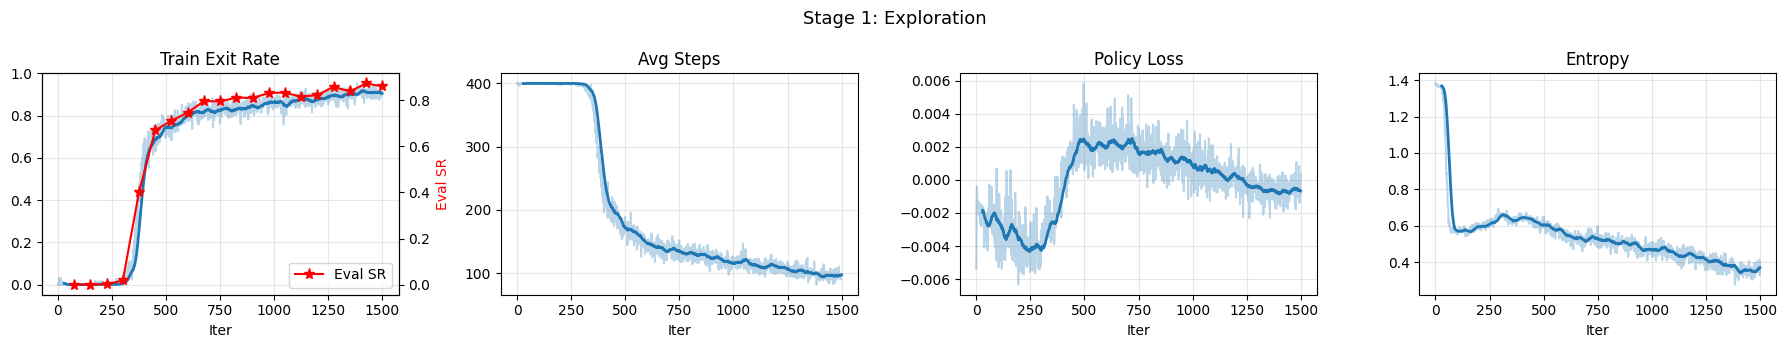


  STAGE 2: Goal-seeking
  iters=1500, lr=0.0002, ent=0.015, target_kl=0.012
  early_stop: target_sr=0.99, stable_needed=3, patience=13
    50/1500 | Exit:77% | Steps:148 | PL:0.0141 | Ent:0.491 | KL:0.0203 | Ep:1 | LR:1.9e-04 | FPS:4469
  ::: EVAL: Success=70.3%, Steps=83.9 *** BEST
stable_check: sr_ok=False | stable=0/3
   100/1500 | Exit:74% | Steps:157 | PL:0.0145 | Ent:0.544 | KL:0.0204 | Ep:1 | LR:1.9e-04 | FPS:4543
   150/1500 | Exit:75% | Steps:161 | PL:0.0133 | Ent:0.547 | KL:0.0155 | Ep:1 | LR:1.8e-04 | FPS:4500
  ::: EVAL: Success=65.0%, Steps=86.0 | no_improve=1/13
stable_check: sr_ok=False | stable=0/3
   200/1500 | Exit:79% | Steps:152 | PL:0.0104 | Ent:0.491 | KL:0.0124 | Ep:1 | LR:1.7e-04 | FPS:4352
  ::: EVAL: Success=73.0%, Steps=81.2 *** BEST
stable_check: sr_ok=False | stable=0/3
   250/1500 | Exit:84% | Steps:131 | PL:0.0070 | Ent:0.454 | KL:0.0111 | Ep:3 | LR:1.7e-04 | FPS:4010
   300/1500 | Exit:81% | Steps:137 | PL:0.0105 | Ent:0.435 | KL:0.0132 | Ep:1 | LR:1.6e

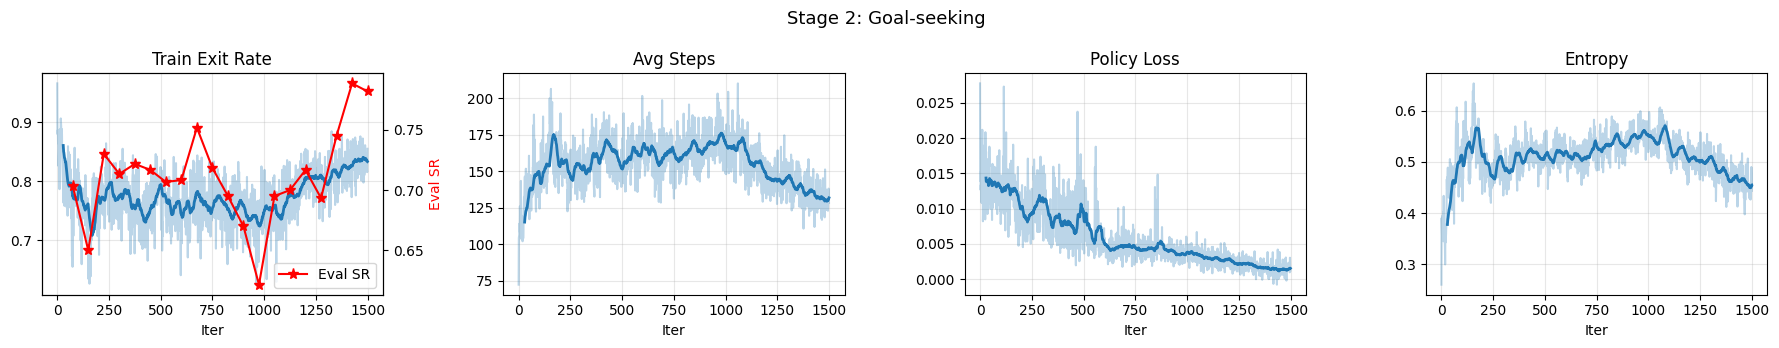


  STAGE 3: Shortest path
  iters=1500, lr=0.0001, ent=0.01, target_kl=0.01
  early_stop: target_sr=0.99, stable_needed=4, patience=13
    50/1500 | Exit:79% | Steps:155 | PL:0.0105 | Ent:0.438 | KL:0.0104 | Ep:1 | LR:9.7e-05 | FPS:3855
  ::: EVAL: Success=68.0%, Steps=85.3 *** BEST
stable_check: sr_ok=False | steps_ok=False (avg_steps=85.3, threshold=57.5) | stable=0/4
   100/1500 | Exit:74% | Steps:171 | PL:0.0143 | Ent:0.485 | KL:0.0155 | Ep:1 | LR:9.3e-05 | FPS:3630
   150/1500 | Exit:74% | Steps:165 | PL:0.0090 | Ent:0.514 | KL:0.0098 | Ep:2 | LR:9.0e-05 | FPS:3450
  ::: EVAL: Success=63.0%, Steps=90.3 | no_improve=1/13
stable_check: sr_ok=False | steps_ok=False (avg_steps=90.3, threshold=57.5) | stable=0/4
   200/1500 | Exit:61% | Steps:207 | PL:0.0061 | Ent:0.550 | KL:0.0083 | Ep:3 | LR:8.7e-05 | FPS:3253
  ::: EVAL: Success=52.2%, Steps=104.3 | no_improve=2/13
stable_check: sr_ok=False | steps_ok=False (avg_steps=104.3, threshold=57.5) | stable=0/4
   250/1500 | Exit:64% | Step

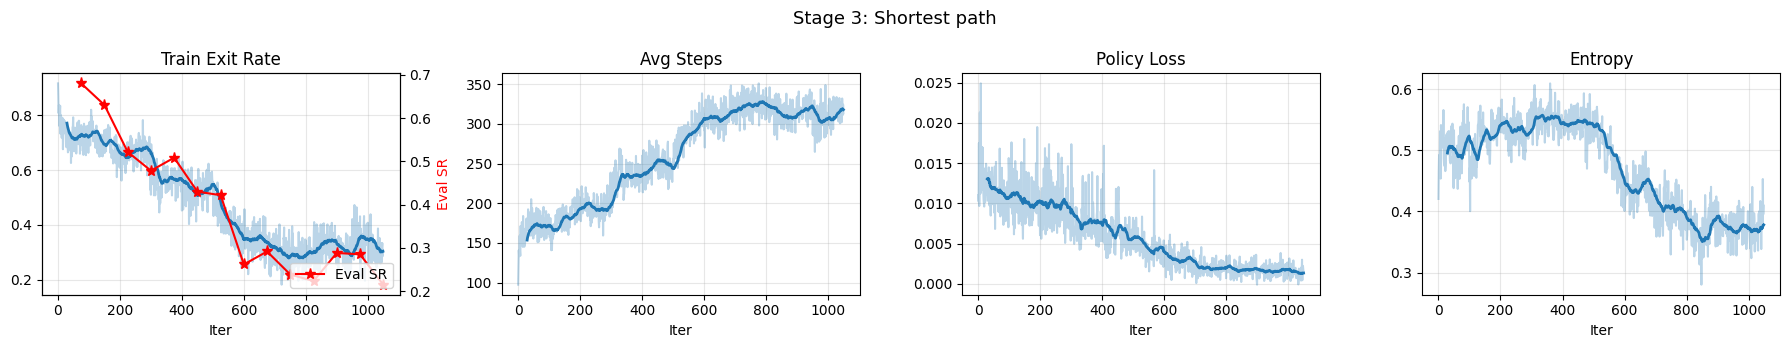

In [25]:
model2 = MazeCNN().to(device)
model2 = train_stage(1, model2)
model2 = train_stage(2, model2)
model2 = train_stage(3, model2)

In [26]:
print('#'*60)
print('  ИТОГОВАЯ ОЦЕНКА НА ТЕСТОВЫХ ЛАБИРИНТАХ')
print('#'*60)
for st in [1,2,3]:
    sr,avs=evaluate_model(model,eval_mazes,eval_dist,eval_sp,st)
    sp_avg = eval_sp.sum(axis=(1,2)).mean()
    print(f'  Stage {st}: Success={sr:.1%}, Avg steps={avs:.1f} (SP avg={sp_avg:.0f})')

############################################################
  ИТОГОВАЯ ОЦЕНКА НА ТЕСТОВЫХ ЛАБИРИНТАХ
############################################################
  Stage 1: Success=65.7%, Avg steps=80.5 (SP avg=50)
  Stage 2: Success=67.0%, Avg steps=80.1 (SP avg=50)
  Stage 3: Success=65.3%, Avg steps=75.3 (SP avg=50)


In [27]:
print('#'*60)
print('  ИТОГОВАЯ ОЦЕНКА НА ТЕСТОВЫХ ЛАБИРИНТАХ')
print('#'*60)
for st in [1,2,3]:
    sr,avs=evaluate_model(model2,eval_mazes,eval_dist,eval_sp,st)
    sp_avg = eval_sp.sum(axis=(1,2)).mean()
    print(f'  Stage {st}: Success={sr:.1%}, Avg steps={avs:.1f} (SP avg={sp_avg:.0f})')

############################################################
  ИТОГОВАЯ ОЦЕНКА НА ТЕСТОВЫХ ЛАБИРИНТАХ
############################################################
  Stage 1: Success=68.8%, Avg steps=86.7 (SP avg=50)
  Stage 2: Success=70.0%, Avg steps=82.8 (SP avg=50)
  Stage 3: Success=69.5%, Avg steps=88.9 (SP avg=50)


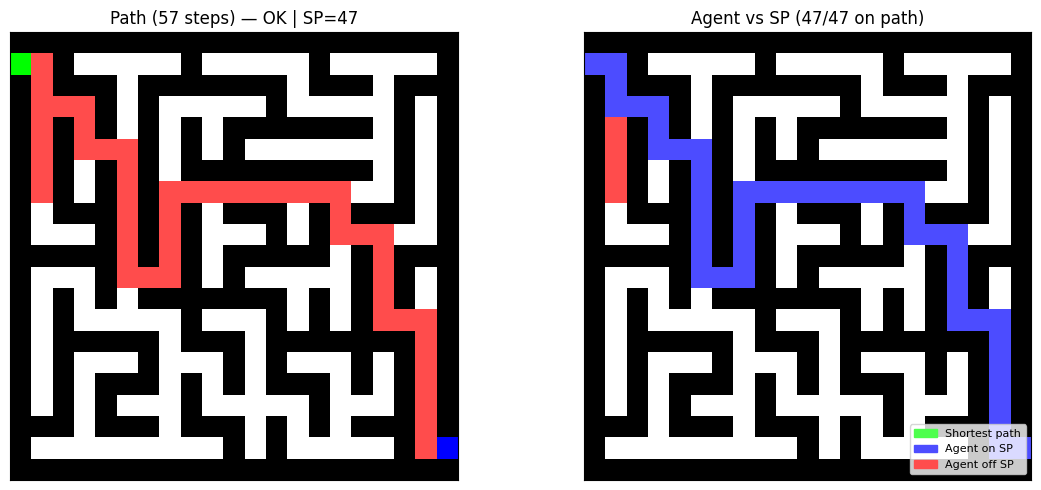

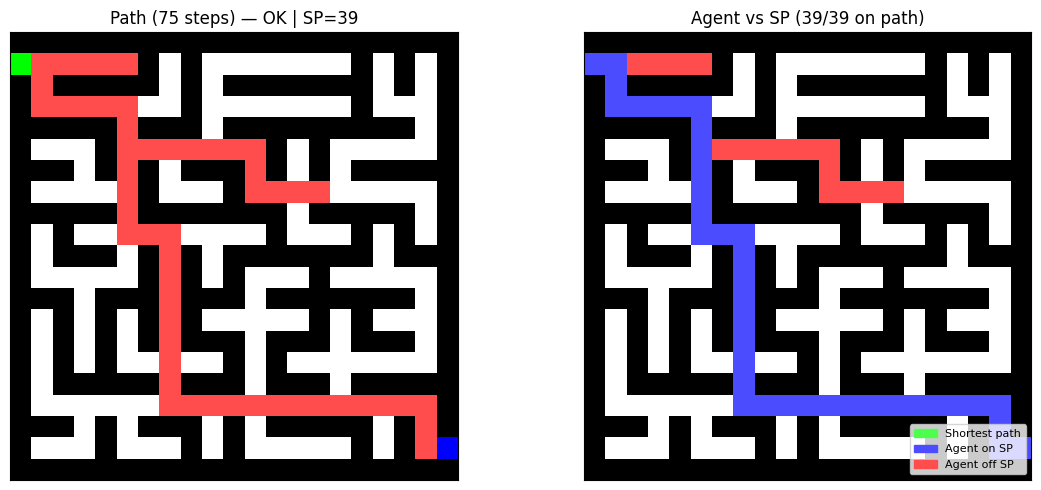

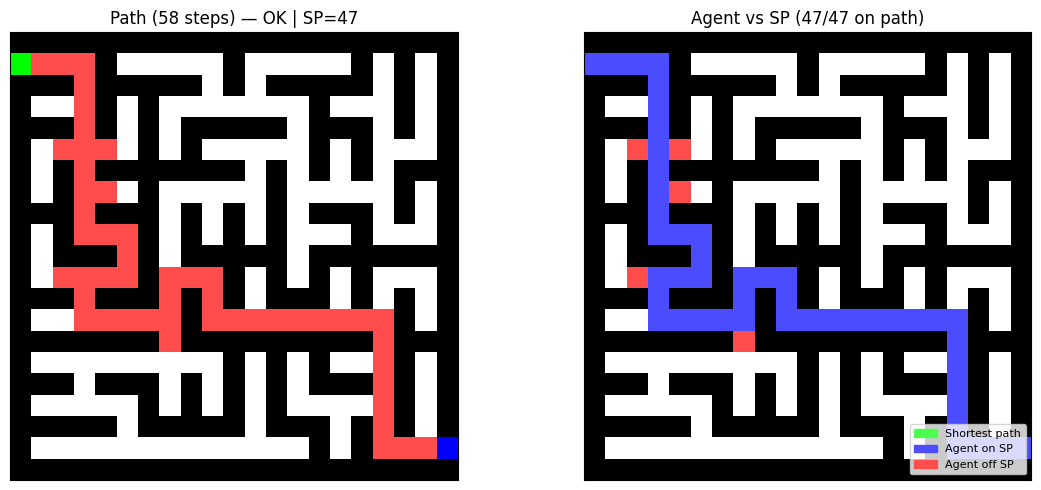

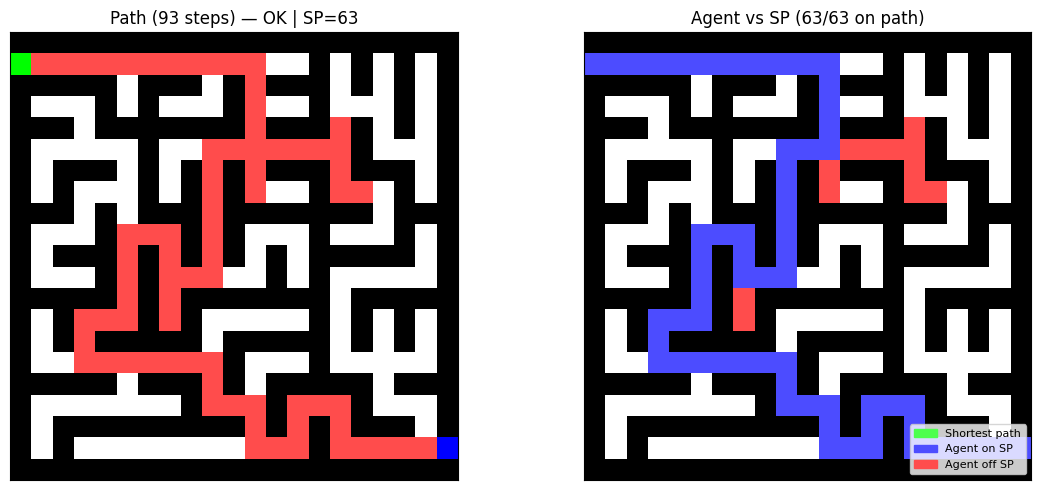

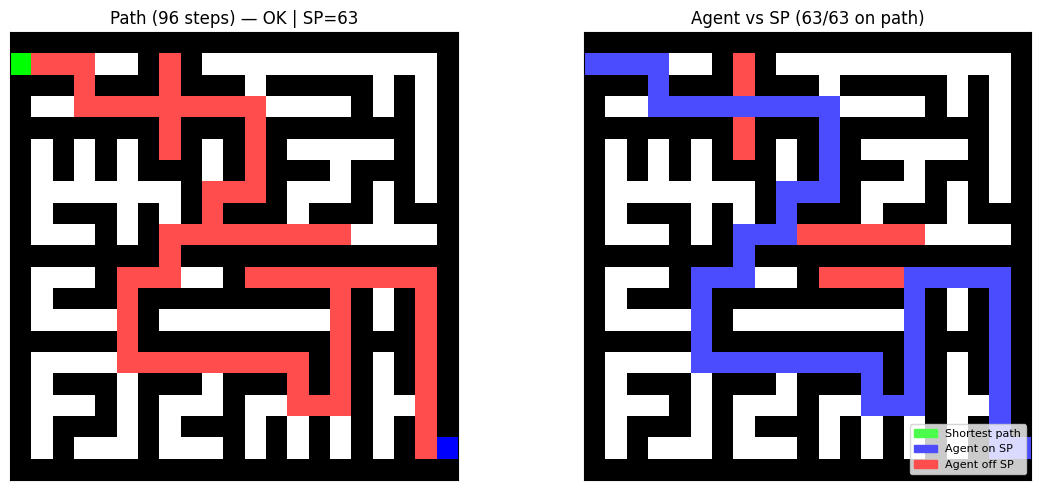

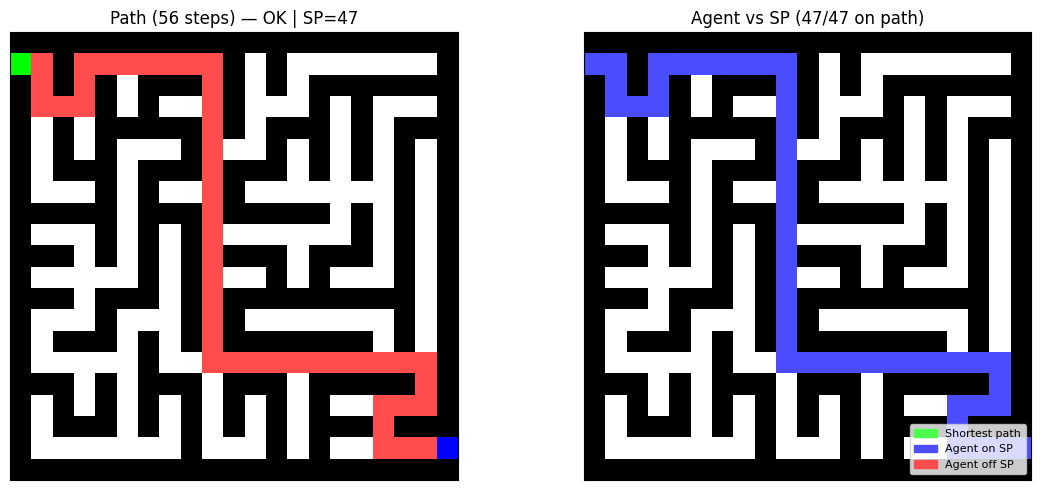

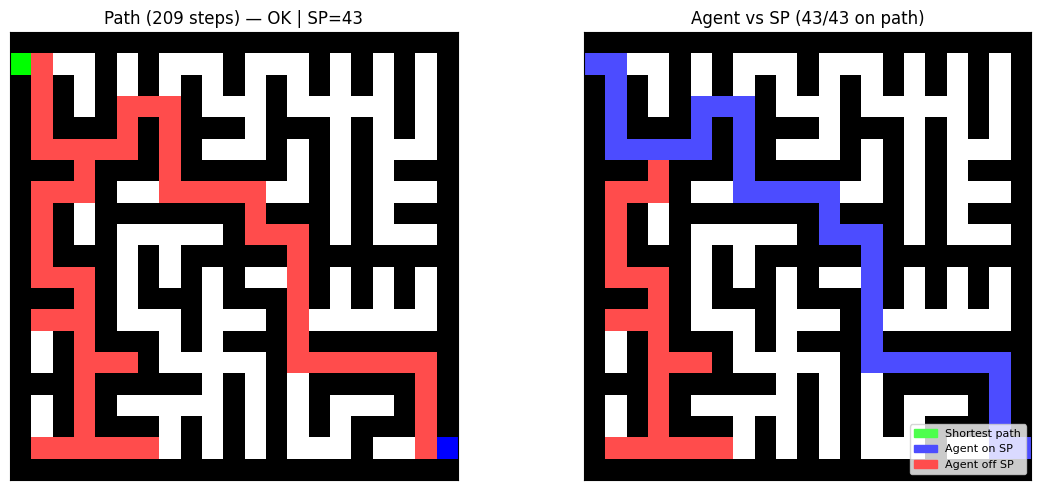

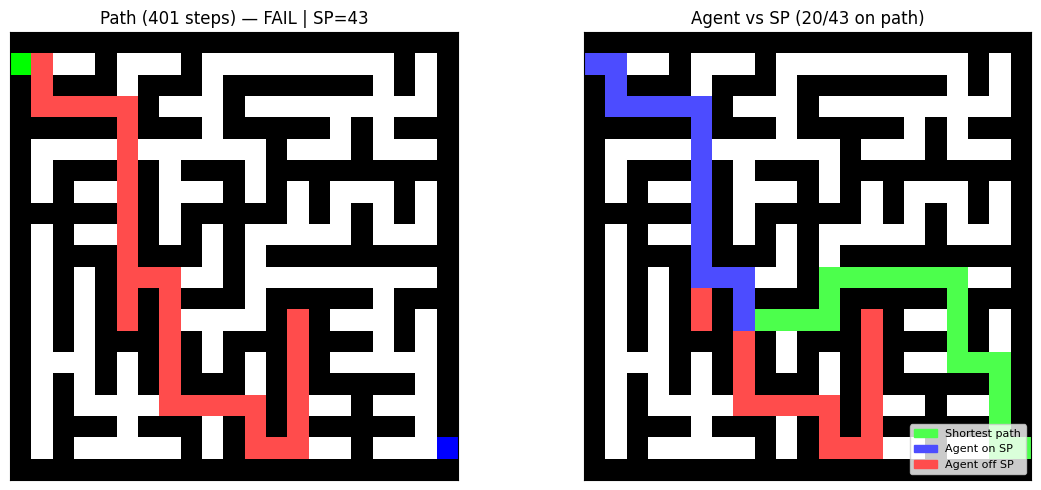

In [28]:
def visualize_solution(model, maze, sp_mask, max_steps=400):
    mf=maze.astype(np.float32); r,c=1,0; path=[(r,c)]
    visited=np.zeros((21,21),dtype=np.float32); visited[r,c]=1.0
    for _ in range(max_steps):
        if r==19 and c==20: break
        obs=np.zeros((1,6,21,21),dtype=np.float32)
        obs[0,0]=mf;obs[0,1,r,c]=1.0;obs[0,2,19,20]=1.0
        obs[0,3]=visited;obs[0,4]=COORD_R;obs[0,5]=COORD_C
        with torch.no_grad():
            actions,_,_,_=model.act(torch.tensor(obs,device=device))
            action=actions.item()
        dr=[1,0,-1,0][action];dc=[0,1,0,-1][action]
        nr,nc=r+dr,c+dc
        if 0<=nr<21 and 0<=nc<21 and maze[nr,nc]==1: r,c=nr,nc
        visited[r,c]=1.0; path.append((r,c))
    reached=(r==19 and c==20)
    sp_len=int(sp_mask.sum())
    on_sp_count=sum(1 for pr,pc in set(path) if sp_mask[pr,pc]>0.5)
    
    fig,axes=plt.subplots(1,2,figsize=(12,5))
    img=np.stack([maze.astype(float)]*3,axis=-1)
    for pr,pc in path: img[pr,pc]=[1,0.3,0.3]
    img[1,0]=[0,1,0]; img[19,20]=[0,0,1]; axes[0].imshow(img)
    axes[0].set_title(f"Path ({len(path)} steps) — {'OK' if reached else 'FAIL'} | SP={sp_len}")
    img2=np.stack([maze.astype(float)]*3,axis=-1)
    for ri,ci in zip(*np.where(sp_mask>0)): img2[ri,ci]=[0.3,1,0.3]
    for pr,pc in path:
        img2[pr,pc]=[0.3,0.3,1] if sp_mask[pr,pc]>0.5 else [1,0.3,0.3]
    axes[1].imshow(img2)
    axes[1].set_title(f'Agent vs SP ({on_sp_count}/{sp_len} on path)')
    axes[1].legend(handles=[
        mpatches.Patch(color=(0.3,1,0.3),label='Shortest path'),
        mpatches.Patch(color=(0.3,0.3,1),label='Agent on SP'),
        mpatches.Patch(color=(1,0.3,0.3),label='Agent off SP'),
    ],loc='lower right',fontsize=8)
    for ax in axes: ax.set_xticks([]);ax.set_yticks([])
    plt.tight_layout(); plt.show()

for _ in range(8):
    i=np.random.randint(len(eval_mazes))
    visualize_solution(model2,eval_mazes[i],eval_sp[i])